In [22]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import time

from numba import cuda

def load_and_display_image(file_path):
        img = mpimg.imread(file_path)

        print(f"Image shape: {img.shape}")

        # plt.imshow(img)
        # plt.axis('off')
        # plt.show()

        return img

image_path = "image.jpg"
img = load_and_display_image(image_path)

h = img.shape[0]
w = img.shape[1]

pixelCount = h*w
blockSize = 64
gridSize = int(pixelCount/blockSize)



Image shape: (6000, 3375, 3)


CPU time: 29.688130378723145 seconds


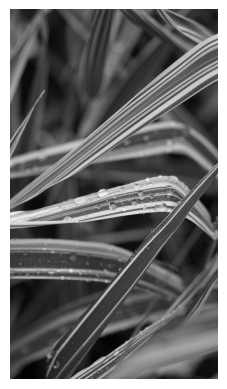

In [2]:
def grayscale_cpu(src):
    gray = np.zeros((h, w, 3), dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            g = (
                int(src[i, j, 0]) +
                int(src[i, j, 1]) +
                int(src[i, j, 2])
            ) / 3

            gray[i, j, 0] = g
            gray[i, j, 1] = g
            gray[i, j, 2] = g

    return gray


start_cpu = time.time()

gray = grayscale_cpu(img)

end_cpu = time.time()

cpu_time = end_cpu - start_cpu

print("CPU time:", cpu_time, "seconds")


gray_image_cpu = gray.reshape((h, w, 3))

plt.imshow(gray_image_cpu)
plt.axis('off')
plt.show()

GPU time: 0.0003058910369873047 seconds


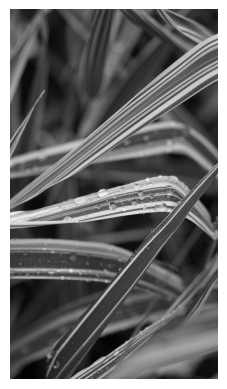

In [34]:
import math
blockSize = (8, 8)

gridSize = (
    math.ceil(w / blockSize[0]),
    math.ceil(h / blockSize[1])
)

@cuda.jit
def grayscale(src, dst):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    if x < src.shape[1] and y < src.shape[0]:
        g = np.uint8(
            (int(src[y, x, 0]) +
             int(src[y, x, 1]) +
             int(src[y, x, 2])) / 3
        )

        dst[y, x, 0] = g
        dst[y, x, 1] = g
        dst[y, x, 2] = g


devSrc = cuda.to_device(img)
devDst = cuda.device_array((h, w, 3), np.uint8)

grayscale[gridSize, blockSize](devSrc, devDst)

hostDst = devDst.copy_to_host()

start_gpu = time.time()

grayscale[gridSize, blockSize](devSrc, devDst)

end_gpu = time.time()

gpu_time = end_gpu - start_gpu

hostDst = devDst.copy_to_host()

print("GPU time:", gpu_time, "seconds")

plt.imshow(hostDst)
plt.axis('off')
plt.show()


In [37]:
block_sizes = [
    (8,8),
    (16,16),
    (32,16),
    (16,32),
    (32,32)
]
gpu_times = []

for blockSize in block_sizes:

    gridSize = (
        math.ceil(w / blockSize[0]),
        math.ceil(h / blockSize[1])
    )

    devSrc = cuda.to_device(img)
    devDst = cuda.device_array((h, w, 3), np.uint8)

    grayscale[gridSize, blockSize](devSrc, devDst)
    hostDst = devDst.copy_to_host()

    times = []

    for i in range(5):

        start = time.time()

        grayscale[gridSize, blockSize](devSrc, devDst)

        end = time.time()

        times.append(end - start)
        hostDst = devDst.copy_to_host()

    average_time = sum(times) / 5

    gpu_times.append(average_time)
    # plt.imshow(hostDst)
    # plt.axis('off')
    # plt.show()

    print("Block size:", blockSize)
    print("Times:", times)
    print("Average:", average_time)

Block size: (8, 8)
Times: [0.00017762184143066406, 0.00014591217041015625, 0.0001423358917236328, 0.00013303756713867188, 0.00019025802612304688]
Average: 0.00015783309936523438
Block size: (16, 16)
Times: [0.0001590251922607422, 0.00015878677368164062, 0.00016546249389648438, 0.00014972686767578125, 0.0001480579376220703]
Average: 0.00015621185302734376
Block size: (32, 16)
Times: [0.00023674964904785156, 0.0002319812774658203, 0.0002770423889160156, 0.0002753734588623047, 0.00025844573974609375]
Average: 0.0002559185028076172
Block size: (16, 32)
Times: [0.00021076202392578125, 0.00019311904907226562, 0.00019359588623046875, 0.00025725364685058594, 0.00019097328186035156]
Average: 0.00020914077758789064
Block size: (32, 32)
Times: [0.0002760887145996094, 0.0002300739288330078, 0.0002288818359375, 0.00022172927856445312, 0.0002484321594238281]
Average: 0.0002410411834716797


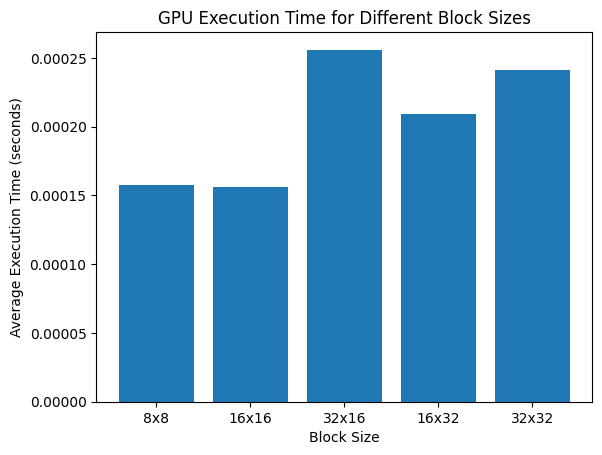

In [39]:
labels = [f"{x}x{y}" for x, y in block_sizes]

plt.bar(labels, gpu_times)

plt.xlabel("Block Size")
plt.ylabel("Average Execution Time (seconds)")
plt.title("GPU Execution Time for Different Block Sizes")

plt.show()